In [1]:
import jax
import jax.numpy as jnp
from jax import random

In [2]:
%load_ext autoreload
%autoreload 2

### Config for the molecule

In [39]:
import sys

from ferminet.utils import system
from ferminet import base_config
from ferminet.configs import p_sys_exp
from ferminet import train

# Define molecule
cfg = p_sys_exp.get_config()

# Set training parameters
cfg.batch_size = 512
cfg.pretrain.iterations = 0
cfg.mcmc.burn_in = 0

### (Optional) Getting ferminet like data object

In [40]:

from ferminet.train import init_electrons
from ferminet import networks
import kfac_jax
import jax.numpy as jnp

batch_size = 512
seed = 23
nspins = cfg.system.electrons
key = jax.random.PRNGKey(seed)

#key, subkey = jax.random.split(sharded_key)

pos = jax.random.normal(
        key,
        (batch_size, 3*sum(nspins))
      )*cfg.mcmc.init_width
spins = jnp.empty(pos.shape)

atoms = jnp.stack([jnp.array(atom.coords) for atom in cfg.system.molecule])
charges = jnp.array([atom.charge for atom in cfg.system.molecule])

# Generate atomic configurations for each walker
batch_atoms = jnp.tile(atoms[None, ...], [batch_size, 1, 1])
batch_atoms = kfac_jax.utils.replicate_all_local_devices(batch_atoms)
batch_charges = jnp.tile(charges[None, ...], [batch_size, 1])
batch_charges = kfac_jax.utils.replicate_all_local_devices(batch_charges)

data_shape = (1, batch_size)
pos = jnp.reshape(pos, data_shape + (-1,))
spins = jnp.reshape(spins, data_shape + (-1,))
data = networks.FermiNetData(
    positions=pos, spins=spins, atoms=batch_atoms, charges=batch_charges
)

### Loading model from checkpoint and evaluating it at walker positions
Still need to figure out how to run mcmc step with it

In [8]:
%pwd

'/mnt/c/Users/Parv/Doc/RA/Projects/ferminet_versions/ferminet'

In [42]:
from ferminet.checkpoint import restore
restore_tuple = restore('ferminet/qmcjax_ckpt_000469.npz')
t = restore_tuple[0]
data = restore_tuple[1]
params = restore_tuple[2]
opt_state = restore_tuple[3]
mcmc_width = restore_tuple[4]

In [43]:
pos = data.positions

In [46]:

from ferminet import constants

mcmc_step, logabs_network, batch_network, sharded_key, data_train, params_train = train.train(cfg)
batch_network_pmapped = constants.pmap(batch_network)


prob_density = jnp.exp(batch_network_pmapped(params, data.positions, data.spins, data.atoms, data.charges)) ** 2

In [47]:
prob_density_ = prob_density[0]

### 3d scatter plot of electron densities weigthed by probability

In [48]:
pos = pos[0]

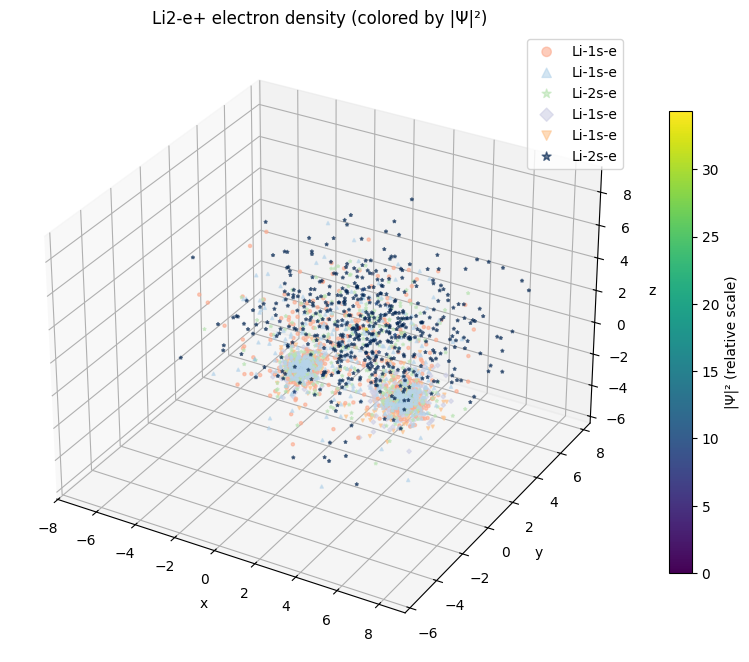

In [50]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.colors as colors
from matplotlib import cm

n_elec = 6
electron_pos = [pos[:, 3*i:3*(i+1)] for i in range(n_elec)]

# Normalize probabilities to [0, 1] for coloring
norm = colors.Normalize(vmin=prob_density_.min(), vmax=prob_density_.max())


def truncate_colormap(cmap, minval=0.3, maxval=1.0, n=256):
    new_cmap = cm.colors.LinearSegmentedColormap.from_list(
        f'trunc({cmap.name},{minval:.2f},{maxval:.2f})',
        cmap(np.linspace(minval, maxval, n)))
    return new_cmap

cmaps = [
    truncate_colormap(plt.cm.Reds, 0.3, 1.0),
    truncate_colormap(plt.cm.Blues, 0.3, 1.0),
    truncate_colormap(plt.cm.Greens, 0.3, 1.0),
    truncate_colormap(plt.cm.Purples, 0.3, 1.0),
    truncate_colormap(plt.cm.Oranges, 0.3, 1.0),
    plt.cm.cividis, plt.cm.plasma, plt.cm.viridis
]

# Pick distinct colormaps (repeat if more electrons than colormaps)
"""
cmaps = [
    plt.cm.Reds, plt.cm.Blues, plt.cm.Greens, plt.cm.Purples, plt.cm.Oranges,
    plt.cm.cividis, plt.cm.plasma, plt.cm.viridis, plt.cm.inferno, plt.cm.copper
]
"""

# Some different marker shapes (will cycle if > len(markers))
markers = ['o', '^', 's', 'D', 'v', '>', '<', 'p', 'h', '*']

fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(111, projection='3d')

scatters = []
for i in range(n_elec):
    cmap = cmaps[i % len(cmaps)]
    marker = markers[i % len(markers)]
    if i == 6:
        sc = ax.scatter(
        electron_pos[i][:,0], electron_pos[i][:,1], electron_pos[i][:,2],
        c=cmap(norm(prob_density_)),
        s=5, alpha=0.6, marker='o', label=f"e+"
    )
    elif (i+1) % 3 == 0:
        sc = ax.scatter(
        electron_pos[i][:,0], electron_pos[i][:,1], electron_pos[i][:,2],
        c=cmap(norm(prob_density_)),
        s=5, alpha=0.6, marker='*', label=f"Li-2s-e"
    )
    else:

        sc = ax.scatter(
            electron_pos[i][:,0], electron_pos[i][:,1], electron_pos[i][:,2],
            c=cmap(norm(prob_density_)),
            s=5, alpha=0.6, marker=marker, label=f"Li-1s-e"
        )
    scatters.append(sc)

# --- Add nuclei from geometry ---
atoms = data.atoms[0][0]  # should be shape (n_atoms, 3)
charges = data.charges[0][0]


ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title("Li2-e+ electron density (colored by |Ψ|²)")
ax.legend(markerscale=3)

# Shared colorbar (take from first scatter)
sm = plt.cm.ScalarMappable(norm=norm, cmap=plt.cm.viridis)
cbar = plt.colorbar(sm, ax=ax, shrink=0.6)
cbar.set_label("|Ψ|² (relative scale)")

plt.show()


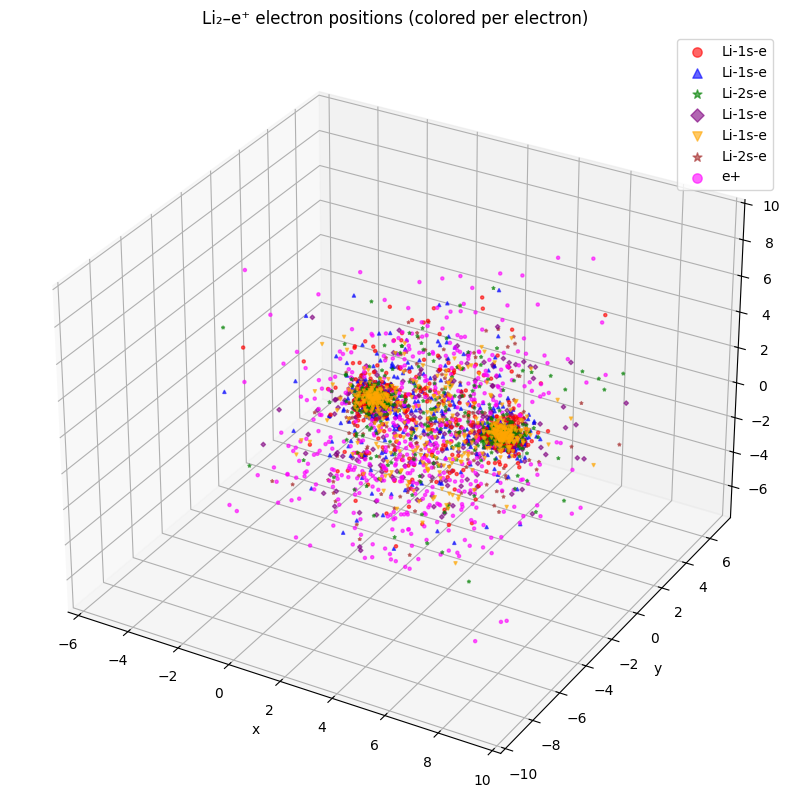

In [26]:
# Without probability weighting
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

n_elec = 7
electron_pos = [pos[:, 3*i:3*(i+1)] for i in range(n_elec)]

# Just pick distinct fixed colors
colors_list = ["red", "blue", "green", "purple", "orange", "brown", "magenta"]

# Marker shapes to differentiate (will cycle if needed)
markers = ['o', '^', 's', 'D', 'v', '>', '<', 'p', 'h', '*']

fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(111, projection='3d')

scatters = []
for i in range(n_elec):
    marker = markers[i % len(markers)]
    color = colors_list[i % len(colors_list)]

    if i == 6:
        sc = ax.scatter(
            electron_pos[i][:,0], electron_pos[i][:,1], electron_pos[i][:,2],
            c=color, s=5, alpha=0.6, marker='o', label="e+"
        )
    elif (i+1) % 3 == 0:
        sc = ax.scatter(
            electron_pos[i][:,0], electron_pos[i][:,1], electron_pos[i][:,2],
            c=color, s=5, alpha=0.6, marker='*', label="Li-2s-e"
        )
    else:
        sc = ax.scatter(
            electron_pos[i][:,0], electron_pos[i][:,1], electron_pos[i][:,2],
            c=color, s=5, alpha=0.6, marker=marker, label="Li-1s-e"
        )

    scatters.append(sc)

# --- Add nuclei from geometry ---
atoms = data.atoms[0][0]  # shape (n_atoms, 3)
charges = data.charges[0][0]

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title("Li₂–e⁺ electron positions (colored per electron)")
ax.legend(markerscale=3)

plt.show()


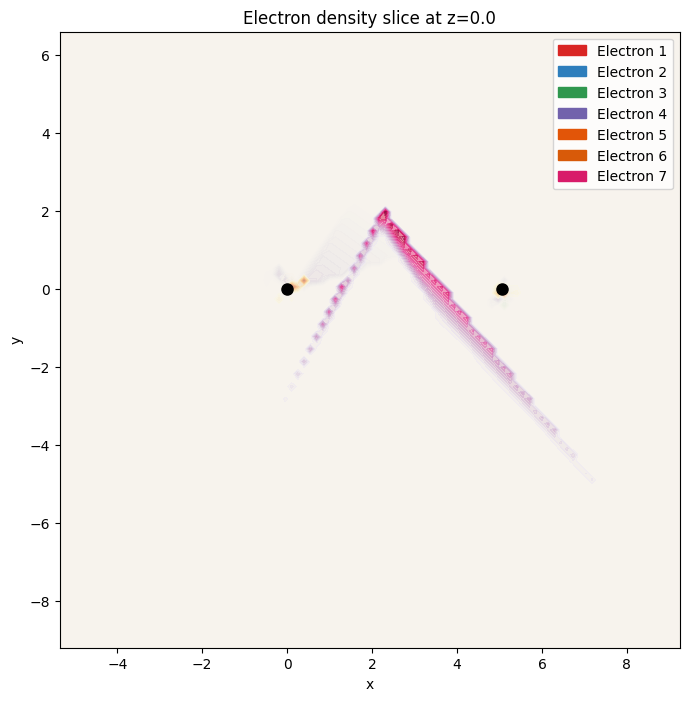

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
import matplotlib.patches as mpatches

# Choose slice along z-axis
z_slice = 0.0  # adjust as needed

# Grid resolution
grid_size = 100

# Prepare 2D grid in x-y
all_pos = np.vstack(electron_pos)
min_bounds = all_pos.min(axis=0)
max_bounds = all_pos.max(axis=0)
x = np.linspace(min_bounds[0], max_bounds[0], grid_size)
y = np.linspace(min_bounds[1], max_bounds[1], grid_size)
X, Y = np.meshgrid(x, y)

fig, ax = plt.subplots(figsize=(8,8))

# Colormaps for each electron
cmaps = ["Reds", "Blues", "Greens", "Purples", "Oranges", "YlOrBr", "PuRd"]

for i in range(n_elec):
    pos = electron_pos[i]
    density = prob_density_[:, i] if prob_density_.ndim==2 else prob_density_

    # Select points near the slice
    mask = np.abs(pos[:,2] - z_slice) < 0.1
    pos_slice = pos[mask]
    density_slice = density[mask]

    if len(pos_slice) == 0:
        continue

    # Interpolate onto 2D grid
    grid = griddata(
        pos_slice[:, :2],
        density_slice,
        (X, Y),
        method='linear',
        fill_value=0
    )

    # Plot filled contour
    ax.contourf(X, Y, grid, levels=20, cmap=cmaps[i % len(cmaps)], alpha=0.5)

# Plot nuclei
for atom in atoms:
    ax.plot(atom[0], atom[1], 'ko', markersize=8)

# --- Legend ---
legend_patches = [mpatches.Patch(color=plt.get_cmap(cmaps[i % len(cmaps)])(0.7),
                                 label=f'Electron {i+1}')
                  for i in range(n_elec)]
ax.legend(handles=legend_patches, loc='upper right')

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title(f"Electron density slice at z={z_slice}")
plt.show()


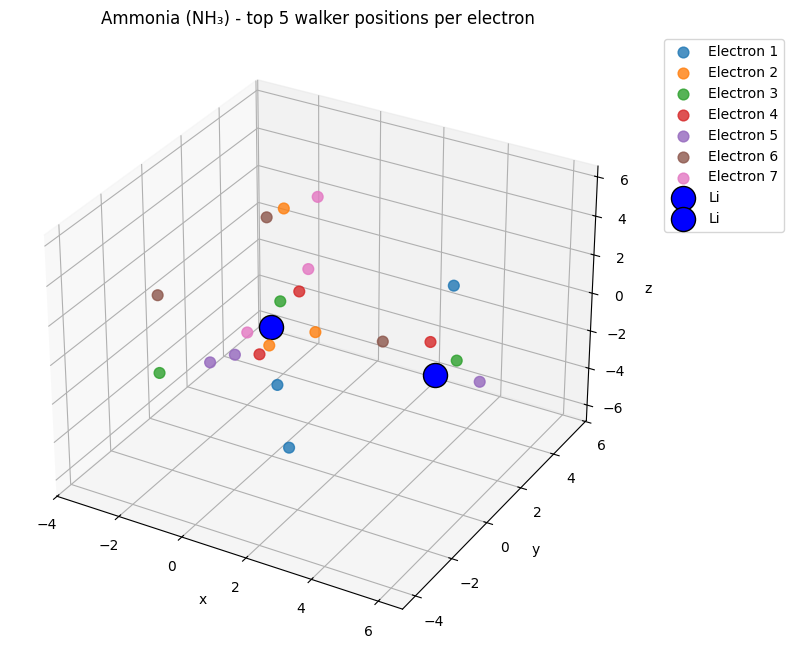

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

n_elec = 7
top_k = 5  # strongest walker positions per electron

# Ensure pos is (n_walkers, n_elec, 3)
if pos.ndim == 2 and pos.shape[1] == 3 * n_elec:
    pos_ = pos.reshape(-1, n_elec, 3)

n_walkers = pos_.shape[0]

# Sort walkers by probability
sorted_idx = np.argsort(prob_density)[::-1]
top_idx = sorted_idx[:top_k]

# Extract electron positions
top_electron_pos = pos_[top_idx]  # (top_k, n_elec, 3)

# Plot setup
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

cmap = plt.get_cmap("tab10")

# Plot electrons
for e in range(n_elec):
    coords = top_electron_pos[:, e, :]  # shape (top_k, 3)
    ax.scatter(
        coords[:, 0], coords[:, 1], coords[:, 2],
        s=60, alpha=0.8, color=cmap(e % 10),
        label=f"Electron {e+1}"
    )

# --- Add nuclei from geometry ---
atoms = data.atoms[0][0]  # should be shape (n_atoms, 3)
charges = data.charges[0][0]

for i, (coord, Z) in enumerate(zip(atoms, charges)):
    #if Z == 7:  # nitrogen
    ax.scatter(*coord, s=300, color="blue", edgecolor="k", label="Li")
    #elif Z == 1:  # hydrogen
    #    ax.scatter(*coord, s=100, color="white", edgecolor="k", label="H")

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title(f"Ammonia (NH₃) - top {top_k} walker positions per electron")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()


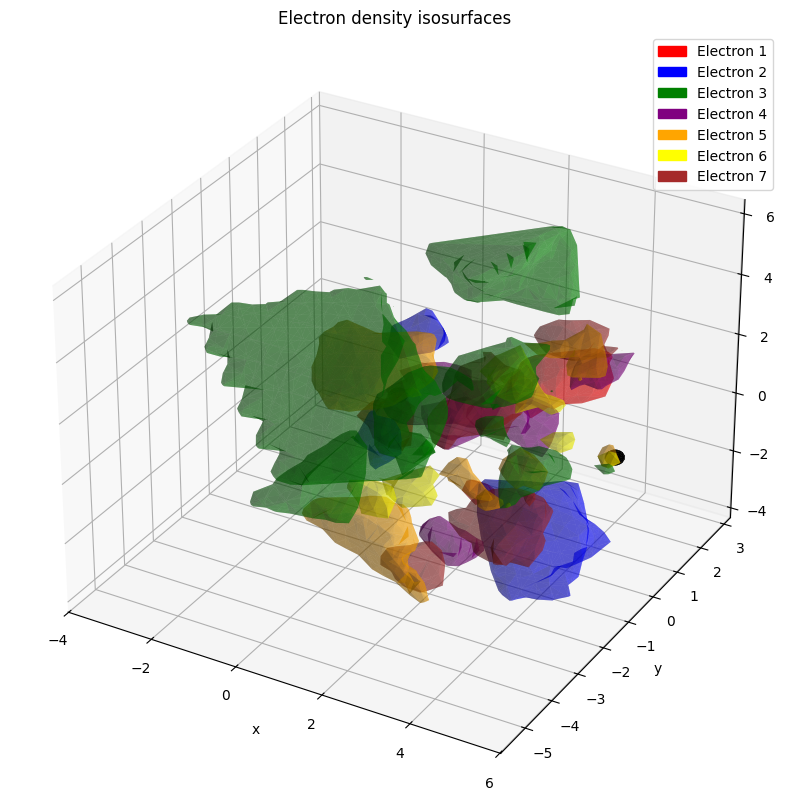

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from skimage.measure import marching_cubes
import matplotlib.patches as mpatches

# --- Assume electron_pos[i] and prob_density_[:, i] are prepared ---
# Example: electron_pos[i] shape: (N_points,3)
#          prob_density_ shape: (N_points,)

n_elec = 7
grid_size = 50

# Create a 3D grid
all_pos = np.vstack(electron_pos)
min_bounds = all_pos.min(axis=0) - 0.5
max_bounds = all_pos.max(axis=0) + 0.5
x = np.linspace(min_bounds[0], max_bounds[0], grid_size)
y = np.linspace(min_bounds[1], max_bounds[1], grid_size)
z = np.linspace(min_bounds[2], max_bounds[2], grid_size)
X, Y, Z = np.meshgrid(x, y, z, indexing='ij')

from scipy.interpolate import griddata

fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(111, projection='3d')

colors_list = ["red", "blue", "green", "purple", "orange", "yellow", "brown"]

for i in range(n_elec):
    # Interpolate density onto grid
    density = prob_density_[:, i] if prob_density_.ndim==2 else prob_density_
    grid = griddata(
        electron_pos[i],  # (N_points,3)
        density,          # (N_points,)
        (X, Y, Z),        # grid
        method='linear',
        fill_value=0
    )

    # Extract an isosurface at 20% of max density
    verts, faces, normals, values = marching_cubes(grid, level=0.2*grid.max(), spacing=(x[1]-x[0], y[1]-y[0], z[1]-z[0]))
    
    # Plot surface
    ax.plot_trisurf(
        verts[:, 0] + min_bounds[0],
        verts[:, 1] + min_bounds[1],
        faces,
        verts[:, 2] + min_bounds[2],
        color=colors_list[i % len(colors_list)],
        alpha=0.4,
        linewidth=0
    )

# Plot nuclei as spheres
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

for atom in atoms:
    u, v = np.mgrid[0:2*np.pi:20j, 0:np.pi:10j]
    xs = 0.2*np.cos(u)*np.sin(v) + atom[0]
    ys = 0.2*np.sin(u)*np.sin(v) + atom[1]
    zs = 0.2*np.cos(v) + atom[2]
    ax.plot_surface(xs, ys, zs, color='black')


# Create proxy artists for the legend
legend_patches = [mpatches.Patch(color=colors_list[i % len(colors_list)], label=f'Electron {i+1}')
                  for i in range(n_elec)]

# Add the legend
ax.legend(handles=legend_patches, loc='upper right')
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title("Electron density isosurfaces")
plt.show()
